# Data Camp: Stress level prediction

Authors: *Lucien Perdrix, Emma de Charry, Pauline Zhou, Thibaud Geffray, Augustin Sanson*



<div style="text-align: center;">
<img src="./img/stress.jpg" width=600px alt="Stressed person"></img>
</div>


## Introduction
Stress has become an unavoidable part of modern life, affecting people of all ages and backgrounds. With increasing workloads, social pressures, financial challenges, and the constant demands of a fast-paced world, stress levels are rising globally. While short-term stress can sometimes be beneficial—helping individuals stay motivated and focused — chronic stress can have serious consequences on both physical and mental health. Factors such as irregular sleep patterns, excessive working hours, poor physical activity, and fluctuating moods can contribute to stress.

Chronic stress can lead to negative consequences like anxiety, fatigue, and even long-term health risks. Understanding and predicting stress levels based on various lifestyle and physiological factors (such as sleep quality, screen on time, ...) can help in early intervention and better stress management strategies.

Our data challenge revolves around predicting stress levels of 100 participants in order to unravel the main causes of stress, and the correlation between different factors.

# Exploratory data analysis

This notebook provides a simple exploratory data analysis of the dataset.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)


In [3]:
import sys
print(sys.executable)


c:\Users\Thibaud\3A\Data_camp_final\env_datacamp_final\Scripts\python.exe


### Load the data

The dataset consists of 3000 rows, representing daily data for 100 participants over a period of 30 days. The data captures various psychological, behavioral, and physiological attributes for each participant. Here are the different features:

participant_id

day

PSS_score: Perceived Stress Scale score, measuring stress levels

Openness

Conscientiousness

Extraversion

Agreeableness

Neuroticism

sleep_time

wake_time

sleep_duration

PSQI_score

call_duration

num_calls

num_sms

screen_on_time

skin_conductance

accelerometer

mobility_radius

mobility_distance

Stress_Category

In [7]:
import problem
X_df, y = problem.get_train_data()
print(type(y))

<class 'numpy.ndarray'>


  
Let's first look at the data available.

In [11]:
print(f"There are {X_df.shape[0]} segment in this dataset.")
X_df.head()

There are 2399 segment in this dataset.


,participant_id,day,Openness,Conscientiousness,Extraversion,Agreeableness,Neuroticism,sleep_time,wake_time,sleep_duration,PSQI_score,call_duration,num_calls,num_sms,screen_on_time,skin_conductance,accelerometer,mobility_radius,mobility_distance
0,1,1,2.322732,4.332193,1.185878,1.570213,3.782094,7.726792,5.190660,6.572069,1,3.924527,12,32,10.703714,3.115730,0.161717,1.145179,2.196851
1,1,2,1.761436,3.254120,3.907281,4.072512,1.997145,7.312674,6.170717,8.030168,4,58.318004,3,41,11.012939,0.959144,0.985587,1.021133,0.737825
2,1,3,3.025887,1.855002,2.045900,2.317493,3.619225,6.992060,5.318825,7.102420,1,4.941043,4,48,4.877372,3.311629,1.877445,0.478179,0.911673
3,1,4,1.948370,4.966676,3.345225,1.607756,3.583524,8.886914,8.061075,8.123294,3,0.295373,11,38,3.462956,0.625721,0.494921,0.630549,3.911418
4,1,5,3.343484,2.065936,3.137843,2.118061,2.567347,7.811705,7.312145,7.785143,3,22.300571,17,17,4.861046,0.622609,1.342600,0.254090,1.605132


Let's have a look on the target distribution. One notices that the category 1 is under represented, it should be taken in account for the prediction model

C:\Users\Thibaud\AppData\Local\Temp\ipykernel_40868\3880804792.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


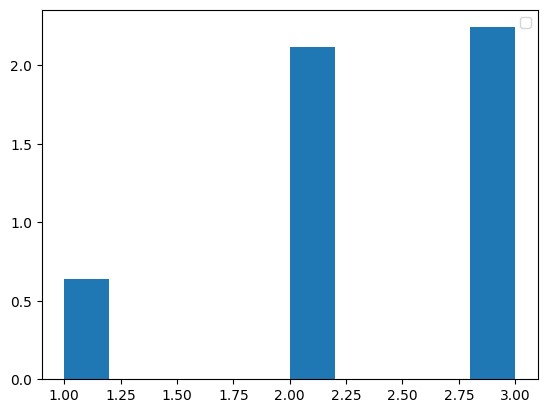

In [24]:
# Now let's check the distribution of the target
plt.hist(y, bins=10, density=True, alpha=1)
plt.legend()

The boxplot illustrates the distribution of a feature across three different stress categories. Each box represents the interquartile range (IQR) of the feature, with the median indicated by a horizontal line inside the box. The whiskers extend to show variability outside the upper and lower quartiles.One has a global view on the features which could impact the stress category

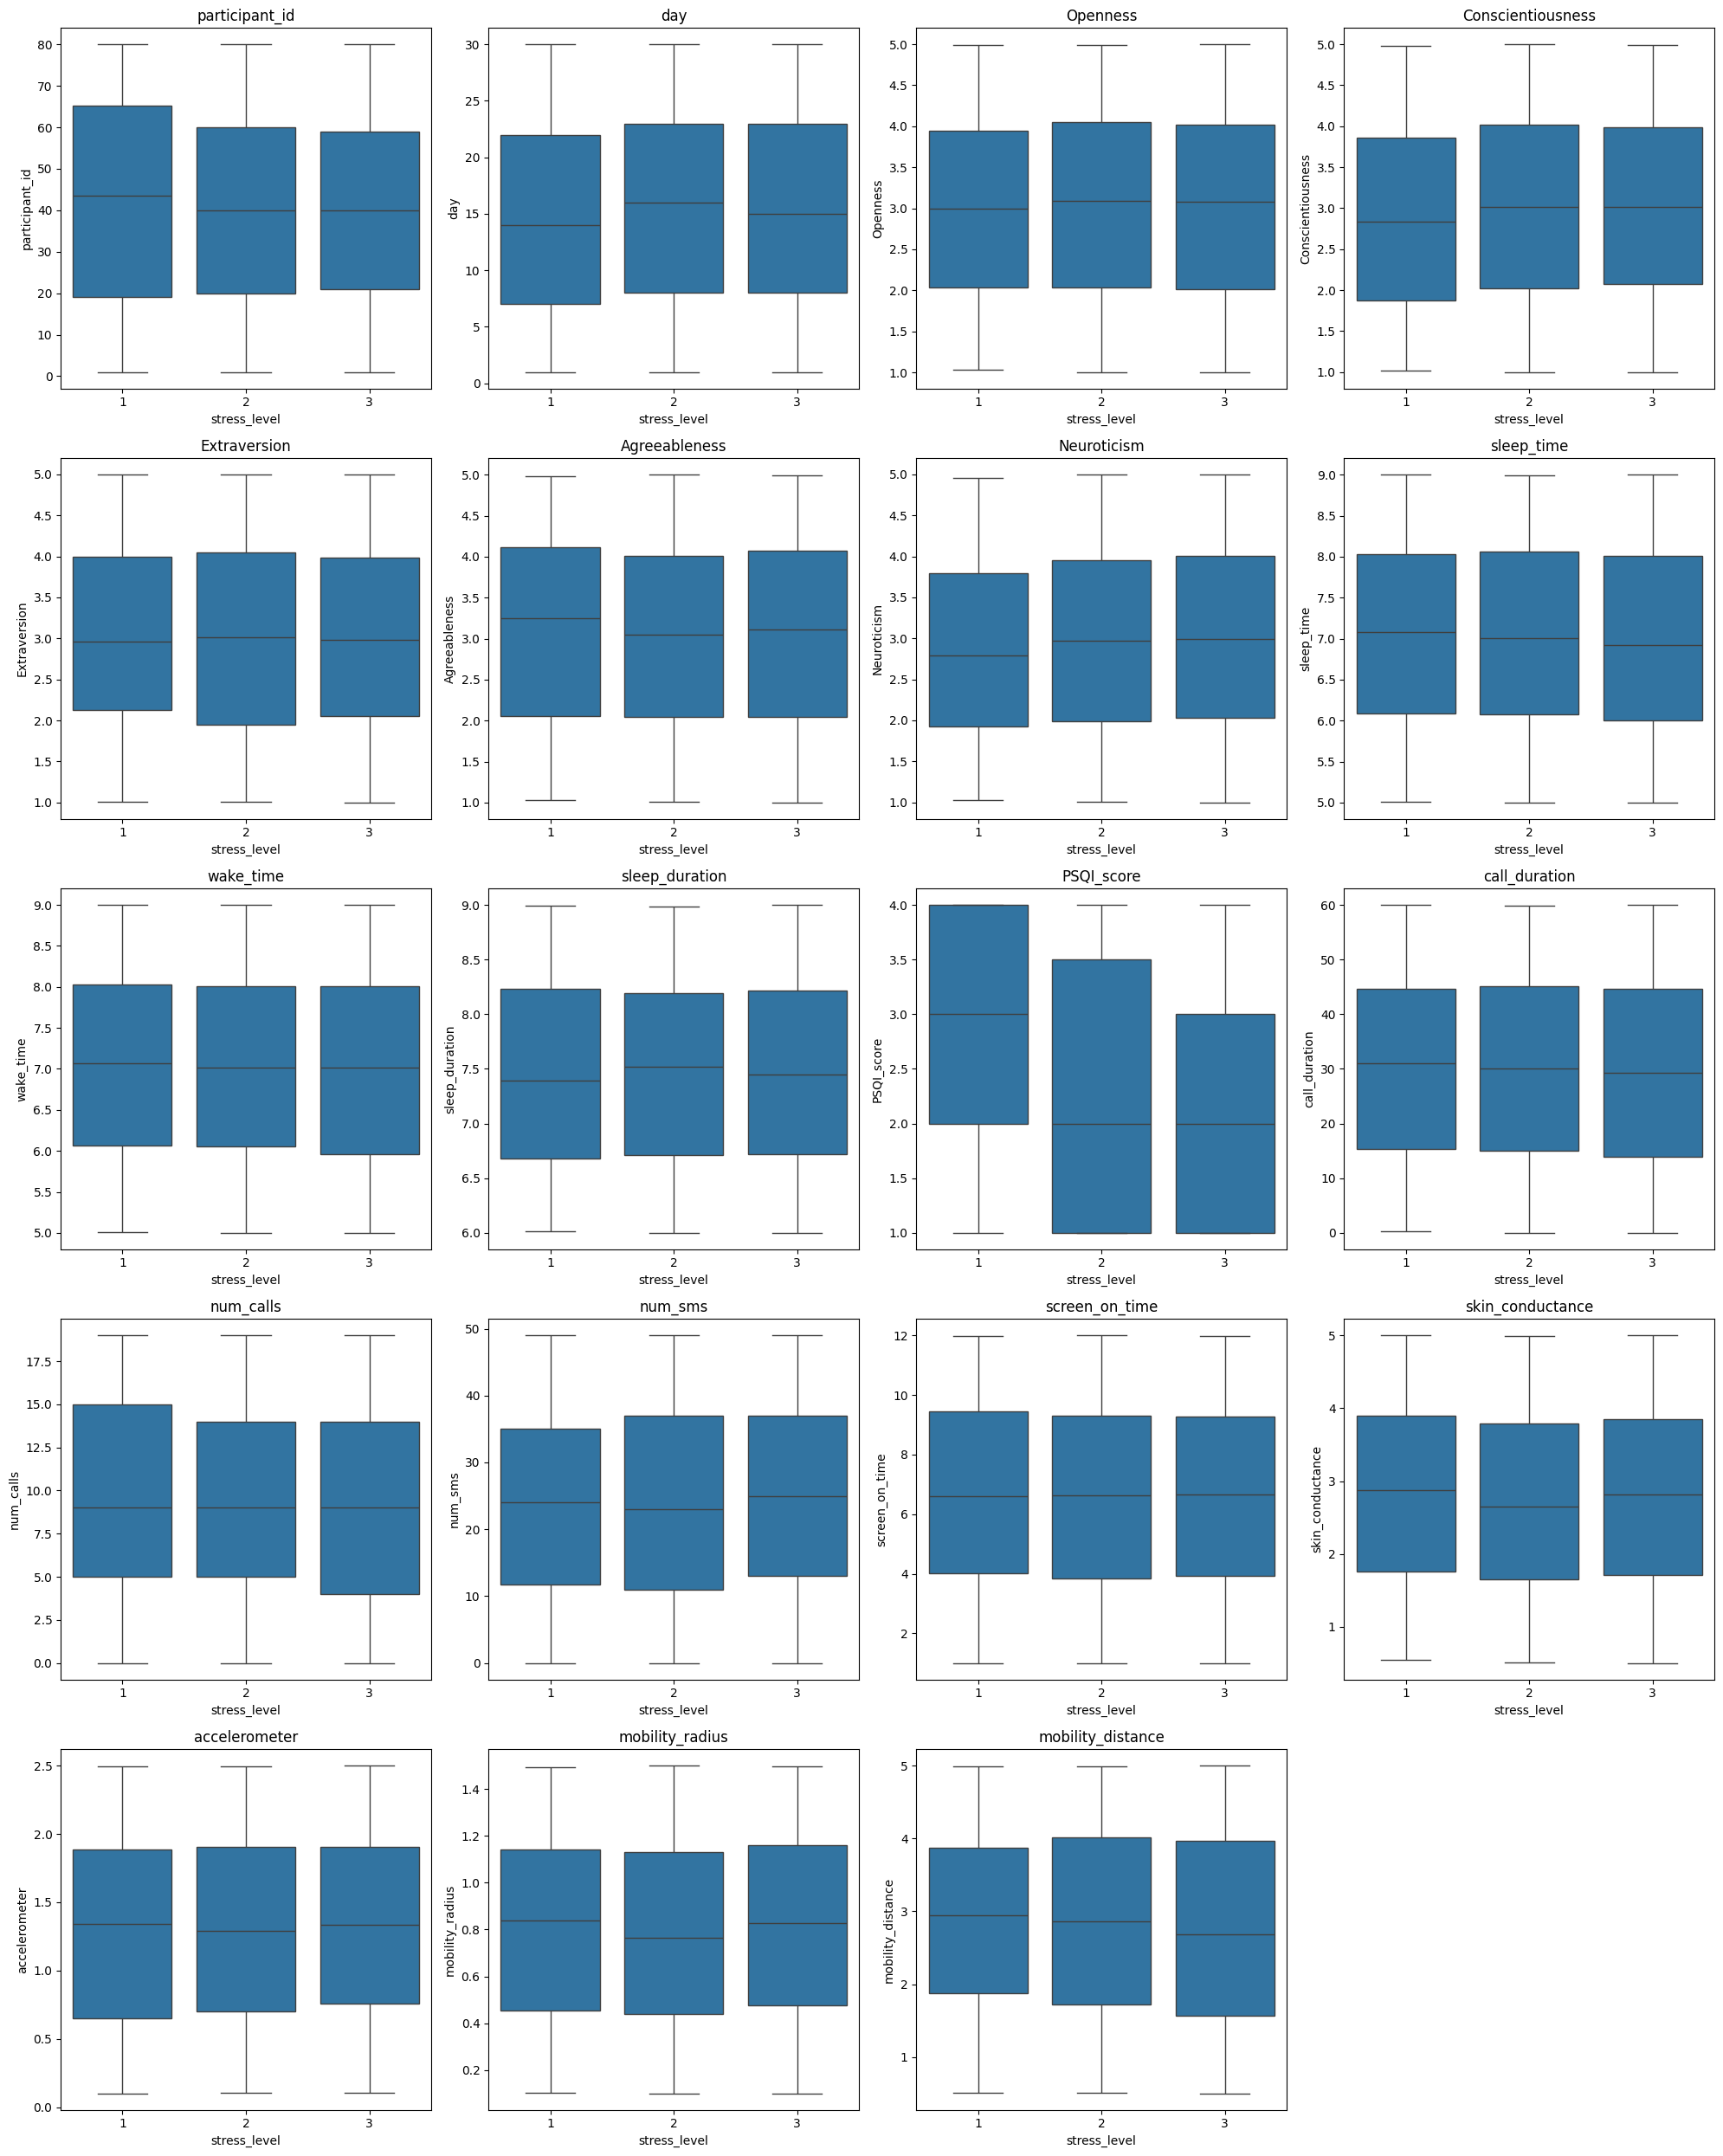

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Supposons que 'X_df' soit votre DataFrame contenant ces features
def plot_boxplots(X_df, y):
    features = [
        "participant_id", "day", "Openness", "Conscientiousness", "Extraversion", "Agreeableness", "Neuroticism",
        "sleep_time", "wake_time", "sleep_duration", "PSQI_score", "call_duration", "num_calls", "num_sms",
        "screen_on_time", "skin_conductance", "accelerometer", "mobility_radius", "mobility_distance"
    ]
    
    num_features = len(features)
    num_cols = 4  # Nombre de colonnes dans la grille
    num_rows = -(-num_features // num_cols)  # Calcul du nombre de lignes en arrondissant vers le haut
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 5 * num_rows))
    axes = axes.flatten()
    
    df = X_df.copy()
    df['stress_level'] = y  # Ajout du niveau de stress
    
    for i, feature in enumerate(features):
        if feature in X_df.columns:
            sns.boxplot(x=df['stress_level'], y=df[feature], ax=axes[i])
            axes[i].set_title(feature)
        else:
            axes[i].axis("off")  # Désactive l'axe si la colonne n'existe pas
    
    # Supprimer les axes vides
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    
    plt.tight_layout()
    plt.show()

# Exemple d'utilisation
X_df, y = problem.get_train_data()
plot_boxplots(X_df, y)


### A first model 

In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge


from sklearn import set_config
set_config(transform_output="pandas")

from sklearn.metrics import mean_absolute_error


X_df, y = problem.get_train_data(load_waveform=False)
X_df_test, y_test = problem.get_test_data(load_waveform=False)



class IgnoreAdapter(RandomForestRegressor):
    def fit(self, X, y):
        X = X[~y.isna()]
        y = y[~y.isna()]
        return super().fit(X, y)

    def predict(self, X):
        return super().predict(X.drop(columns=["domain"]))


clf = make_pipeline(
    make_column_transformer(
        ("passthrough", ["age"]),
        (OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ["gender"]),
    ),
    RandomForestRegressor(n_estimators=50)
    # Ridge(alpha=1)
)
clf.fit(X_df, y)
print(f"Score on train: {mean_absolute_error(clf.predict(X_df), y)}")
print(f"Score on test: {mean_absolute_error(clf.predict(X_df_test), y_test)}")

Score on train: 4.27142289555519
Score on test: 4.27142289555519


# Submission format

Here, you should describe the submission format. This is the format the participants should follow to submit their predictions on the RAMP plateform.

This section also show how to use the `ramp-workflow` library to test the submission locally.

## The pipeline workflow

The input data are stored in a dataframe. To go from a dataframe to a numpy array we will use a scikit-learn column transformer. The first example we will write will just consist in selecting a subset of columns we want to work with.

In [14]:
# %load submissions/starting_kit/estimator.py

from sklearn import set_config
from sklearn.pipeline import make_pipeline
from sklearn.compose import make_column_transformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OrdinalEncoder

set_config(transform_output="pandas")


class IgnoreDomain(RandomForestRegressor):
    def fit(self, X, y):
        # Ignore the samples with missing target
        X = X[y != -1]
        y = y[y != -1]
        return super().fit(X, y)


def get_estimator():
    return make_pipeline(
        make_column_transformer(
            ("passthrough", ["age"]),
            (OrdinalEncoder(
                handle_unknown='use_encoded_value', unknown_value=-1
            ), ["gender"]),
        ),
        IgnoreDomain(n_estimators=50)
    )


## Testing using a scikit-learn pipeline

In [15]:
import problem
from sklearn.model_selection import cross_val_score

X_df, y = problem.get_train_data()

scores = cross_val_score(get_estimator(), X_df, y, cv=5, scoring='neg_mean_absolute_error')
print(scores)

[-11.46421526 -16.6859301  -63.1603419  -88.11026257 -69.03063582]


In [19]:
X_test, y_test = problem.get_test_data()

In [20]:
X_test.head()

,n_seg,subject,age,gender,domain,id,ecg,ppg
0,470,p090269,76.0,M,m,186.0,"[0.0936607652769846, 0.105653912050257, 0.0822...","[0.1639065817409766, 0.15796178343949044, 0.15..."
1,470,p090269,76.0,M,m,186.0,"[0.23204596233641878, 0.26141078838174275, 0.2...","[0.49115255858440937, 0.42850310856049734, 0.3..."
2,470,p090269,76.0,M,m,186.0,"[0.20232558139534884, 0.14883720930232555, 0.1...","[0.4862650602409639, 0.41927710843373495, 0.36..."
3,470,p090269,76.0,M,m,186.0,"[0.09547069271758439, 0.14076376554174072, 0.1...","[0.6220546654099907, 0.6936852026390199, 0.758..."
4,470,p090269,76.0,M,m,186.0,"[0.09005847953216374, 0.07192982456140351, 0.1...","[0.5684306569343065, 0.6012773722627739, 0.628..."


In [16]:
X_df.head()

,n_seg,subject,age,gender,domain,height,weight,bmi,id,ecg,ppg,chunk
0,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.3688673837817671, 0.3620627421921535, 0.365...","[0.40960445864963035, 0.36931866813001185, 0.3...",NaN
1,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.25735809742643956, 0.23910011930527947, 0.2...","[0.36706728559046503, 0.4034043141571599, 0.35...",NaN
2,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.13428866369506492, 0.14334834365416743, 0.1...","[0.7494333513716098, 0.8147798178151058, 0.799...",NaN
3,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.17744878960204316, 0.18312116528072353, 0.2...","[0.2668839934294831, 0.26939094339014175, 0.25...",NaN
4,688,p000750,78.0,M,v,162.0,50.6,19.3,1.0,"[0.6703874816047055, 0.5075806829705767, 0.444...","[0.27162392568169147, 0.2647447495713346, 0.24...",NaN


In [17]:
X_df.columns

Index(['n_seg', 'subject', 'age', 'gender', 'domain', 'height', 'weight',
       'bmi', 'id', 'ecg', 'ppg', 'chunk'],
      dtype='object')